# Fitting the landscape model to scRNA-seq
*First-decisions landscape (NMP → PreNeural / Mesoderm; PreNeural → EarlyVentral / p0p1)*

<br> 

In this notebook, we simulate and fit the landscape model in [1] comprising the decisions from days D3 to D4. We use the scRNA-seq data from mouse embryonic stem cells generated in response to **500nM SAG** treatment [2]. **The landscape comprises two binary flip decisions, one from NMP to either PreNeural (Neural tube precursor state) or Mesoderm, another from PreNeural to either EarlyVentral (Foxa2 expressing cells) or Pax6-expressing cells labelled p0/p1.** The fitting machinery is in `fitting_core.py`, the landscape model in `landscape_first_decisions.py`, and the plotting helpers in `fitting_plots.py`.

The simulation and fitting procedures are detailed in Appendix B (Modelling & estimation) [3] of [1]:

* __Section B3:__ Parameterising and simulating the landscape,
* __Section B4:__ Fitting the model to simulated proportions.
  
[1] M. Fontaine, J.M. Delas, M. Saez, R.J. Maizels, E. Finnie, J. Briscoe, D.A. Rand, (2025). *Dynamic Landscape Analysis of Cell Fate Decisions: Predictive Models of Neural Development From Single-Cell Data*. bioR$\chi$iv doi: https://doi.org/10.1101/2025.05.28.656648.

[2] Maizels R.J., Snell D.M., Briscoe J. (2024). *Reconstructing developmental trajectories using latent dynamical systems and time-resolved transcriptomics*. Cell Syst, 15(5), https://doi.org/10.1016/j.cels.2024.04.004.

[3] M. Fontaine, J.M. Delas, M. Saez, R.J. Maizels, E. Finnie, J. Briscoe, D.A. Rand, (2025). *Appendix B: Modelling & estimation*. figshare doi: https://doi.org/10.6084/m9.figshare.31342816.



![Alt text](Github_SimulationNMP.jpg)

---
<sub>Author: Marine Fontaine (Warwick)</sub>

### **1.** Load packages

In [1]:
import os
import sys
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **2.** Import experimental proportions

In [3]:
wd = 'Experimental_and_Simulated_Proportions_NMPTransition/'  # relative to this notebook

adata = pd.read_csv(wd + 'Proportions_RNAseq_FirstDecisions.csv')

# Combine columns Meso+EarlyMeso and p0/p1+pMNTrans for this example
adata1 = adata.drop(columns=['EarlyMeso', 'NMPTrans', 'PreNTrans', 'pMNTrans'])
adata1['Meso'] = adata['Meso'] + adata['EarlyMeso']
adata1['p0/p1'] = adata['p0/p1'] + adata['pMNTrans']

# Normalise and round the data
processed_data = np.round(adata1.to_numpy() / 100, 2)

# Flatten into a dictionary for Pyabc
Xdata = {'X_2': processed_data.flatten()}
adata1

,Meso,NMP,PreNeural,p0/p1,EarlyVentral
0,5.025579,84.953355,0.872705,0.000000,0.000000
1,5.093555,65.835066,9.805960,0.034650,0.103950
2,9.859585,34.890110,20.054945,0.213675,0.183150
3,12.997064,10.141446,42.113691,2.295169,0.640512
4,14.085765,2.709946,43.627159,13.222156,4.020250
5,26.317860,0.983478,4.720692,37.018096,12.411487


### **3.** Setting up the model

**Setting up the model.** The fitting machinery lives in `fitting_core`; the *model* is the landscape function you pass to it. The cell below brings the pieces together:

- **`compute_landscape`** (from a `landscape_*` module) — the model itself: the drift + noise of the landscape at each point. Pass a different one (or your own `@njit` function) to fit a different model.
- **`cellstates`** — the approximated attractor positions (one `[x, y]` per state; approximate because an attractor can move when the parameters change). Cells within `radius` of a cellstate are counted as that state when computing proportions.
- **`parSDE`** — the SDE settings (time step, total time, number of cells, measurement times); taken from the landscape's `default_parSDE`.
- **`start_centers` / `samples`** — the initial condition: cells start from a Meso / NMP / PreNeural mixture. Edit these to start from a different mixture.
- **`make_model(...)`** — builds the PyABC model that simulates the SDE and returns the per-timepoint cluster proportions.
- **`make_distance(...)`** — builds the PyABC distance; the first-decisions fit keeps all timepoints, so nothing is dropped.

The last lines run a quick test: simulate one parameter set and measure its distance to the data.

In [4]:
# --- Choosing the model ---
# Machinery is model-agnostic (fitting_core). The MODEL is the compute_landscape
# you pass to make_model. Here we use the provided first-decisions landscape;
# to use your own model, just define your own compute_landscape and pass it instead.
from fitting_core import make_model, make_distance
from landscape_first_decisions import compute_landscape, cellstates, default_parSDE

# (cellstates / parSDE come with the landscape; override them here if you want.)
parSDE = default_parSDE

# Cells start from a Meso / NMP / PreNeural mixture (~5% / 85% / 10%)
start_centers = [(3, 4.8), (1.40765, 6.86026), (1.4, 6.4)]  # Meso, NMP, PreNeural
samples = [int(5*parSDE['ncells']/100), int(85*parSDE['ncells']/100), int(10*parSDE['ncells']/100)]

# Build the model (pass YOUR compute_landscape here to fit a different model) and
# the distance (first-decisions keeps all timepoints -> drop nothing).
model = make_model(compute_landscape, cellstates, parSDE,
                   samples=samples, start_centers=start_centers, radius=0.4)
distance = make_distance()

# Quick test: simulate with example parameters and check the distance to the data
pars_test={'noiseA': 0.341383459334892,'u1': -0.12299580741186507,'u2': -0.5074945071736476,'v1': -1.6266203117774218,'v2': -1.7269934289887667,'velA': 0.8444866800674377}
Xsim_test=model(pars_test)
distance(Xsim_test, Xdata)

0.8059999999999999

### **4.** ABC Fitting

To fit the model we use the PyABC package developed for Python in [4,5].
The procedure begins by defining priors distributions for the parameters $\mathbf{p}=(u_1,v_1,u_2,v_2,\sigma_A,vel_A)$. In our case these are uniform distributions supported in the parameter domain $D$ of the stochastic differential equation. Here we use a sampling population of $N=1500$ and a maximal number of 8 generations. See Appendix B Section B4 in [3] for details.

[4] Schälte, Y. and Klinger, E. and Alamoudi, E. and Hasenauer, J., (2022). *pyABC: Efficient and robust easy-to-use approximate Bayesian computation*. Journal of Open Source Software, 7(74), 4304, https://doi.org/10.21105/joss.04304.

[5] E. Klinger, D. Rickert, and J. Hasenauer, (2018). *pyABC: distributed, likelihood-free inference*. Bioinformatics, 34(20). https://doi.org/10.1093/bioinformatics/bty361.

In [5]:
import pyabc
from pyabc import ABCSMC, RV, Distribution, LocalTransition, MedianEpsilon
from pyabc.visualization import plot_kde_matrix

# Create path to store Pyabc history
path = '/Users/marinefontaine/Documents/Python/DynamicalLandscapeAnalysis_v2/FittingModel/Tutorial'
db_path = "sqlite:///" + os.path.join(tempfile.gettempdir(), "FittingFirstDecisions.db")


# Population size (number of accepted particles per ABC generation).
# Defined once here and reused by ABCSMC and process_simulations.
population_size = 1500

# Define priors
limits = dict(
              u1=(-1, 1),
              v1=(-2.5, -1),
              u2=(-1,1),
              v2=(-2.5, -1),
              noiseA=(0.2, 0.8),
              velA=(0.05,1.2))
prior = Distribution(**{key: RV("uniform", a, b - a)
for key, (a,b) in limits.items()})

In [6]:
# Run ABC
abc = ABCSMC(
    models=model,
    parameter_priors=prior,
    distance_function=distance,
    population_size=population_size,
    transitions=LocalTransition(k_fraction=0.3),
    eps=pyabc.QuantileEpsilon(alpha=0.2),
)

abc.new(db_path, Xdata);

h = abc.run(minimum_epsilon=0.1, max_nr_populations=8)
run_id = h.id
print("Run ID:", run_id)

ABC.Sampler INFO: Parallelize sampling on 12 processes.
ABC.History INFO: Start <ABCSMC id=2, start_time=2026-08-16 12:27:37>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 3.21100000e+00.
ABC INFO: Accepted: 1500 / 7987 = 1.8781e-01, ESS: 1.5000e+03.
ABC INFO: t: 1, eps: 2.20200000e+00.
ABC INFO: Accepted: 1500 / 10361 = 1.4477e-01, ESS: 1.3705e+03.
ABC INFO: t: 2, eps: 1.67600000e+00.
ABC INFO: Accepted: 1500 / 12939 = 1.1593e-01, ESS: 1.3366e+03.
ABC INFO: t: 3, eps: 1.39000000e+00.
ABC INFO: Accepted: 1500 / 14319 = 1.0476e-01, ESS: 1.2394e+03.
ABC INFO: t: 4, eps: 1.19000000e+00.
ABC INFO: Accepted: 1500 / 17865 = 8.3963e-02, ESS: 1.2555e+03.
ABC INFO: t: 5, eps: 1.04400000e+00.
ABC INFO: Accepted: 1500 / 25441 = 5.8960e-02, ESS: 1.1859e+03.
ABC INFO: t: 6, eps: 9.30000000e-01.
ABC INFO: Accepted: 1500 / 24965 = 6.0084e-02, ESS: 1.2079e+03.
ABC INFO: t: 7, eps: 8.41678920e-01.
ABC INFO: Accepted: 1500 / 30420 = 4.9310e-02, ESS: 1.2368e+03.
ABC INFO: Stop: Maximum number

Run ID: 2


#### **4.1** Visualise the posterior parameter distributions

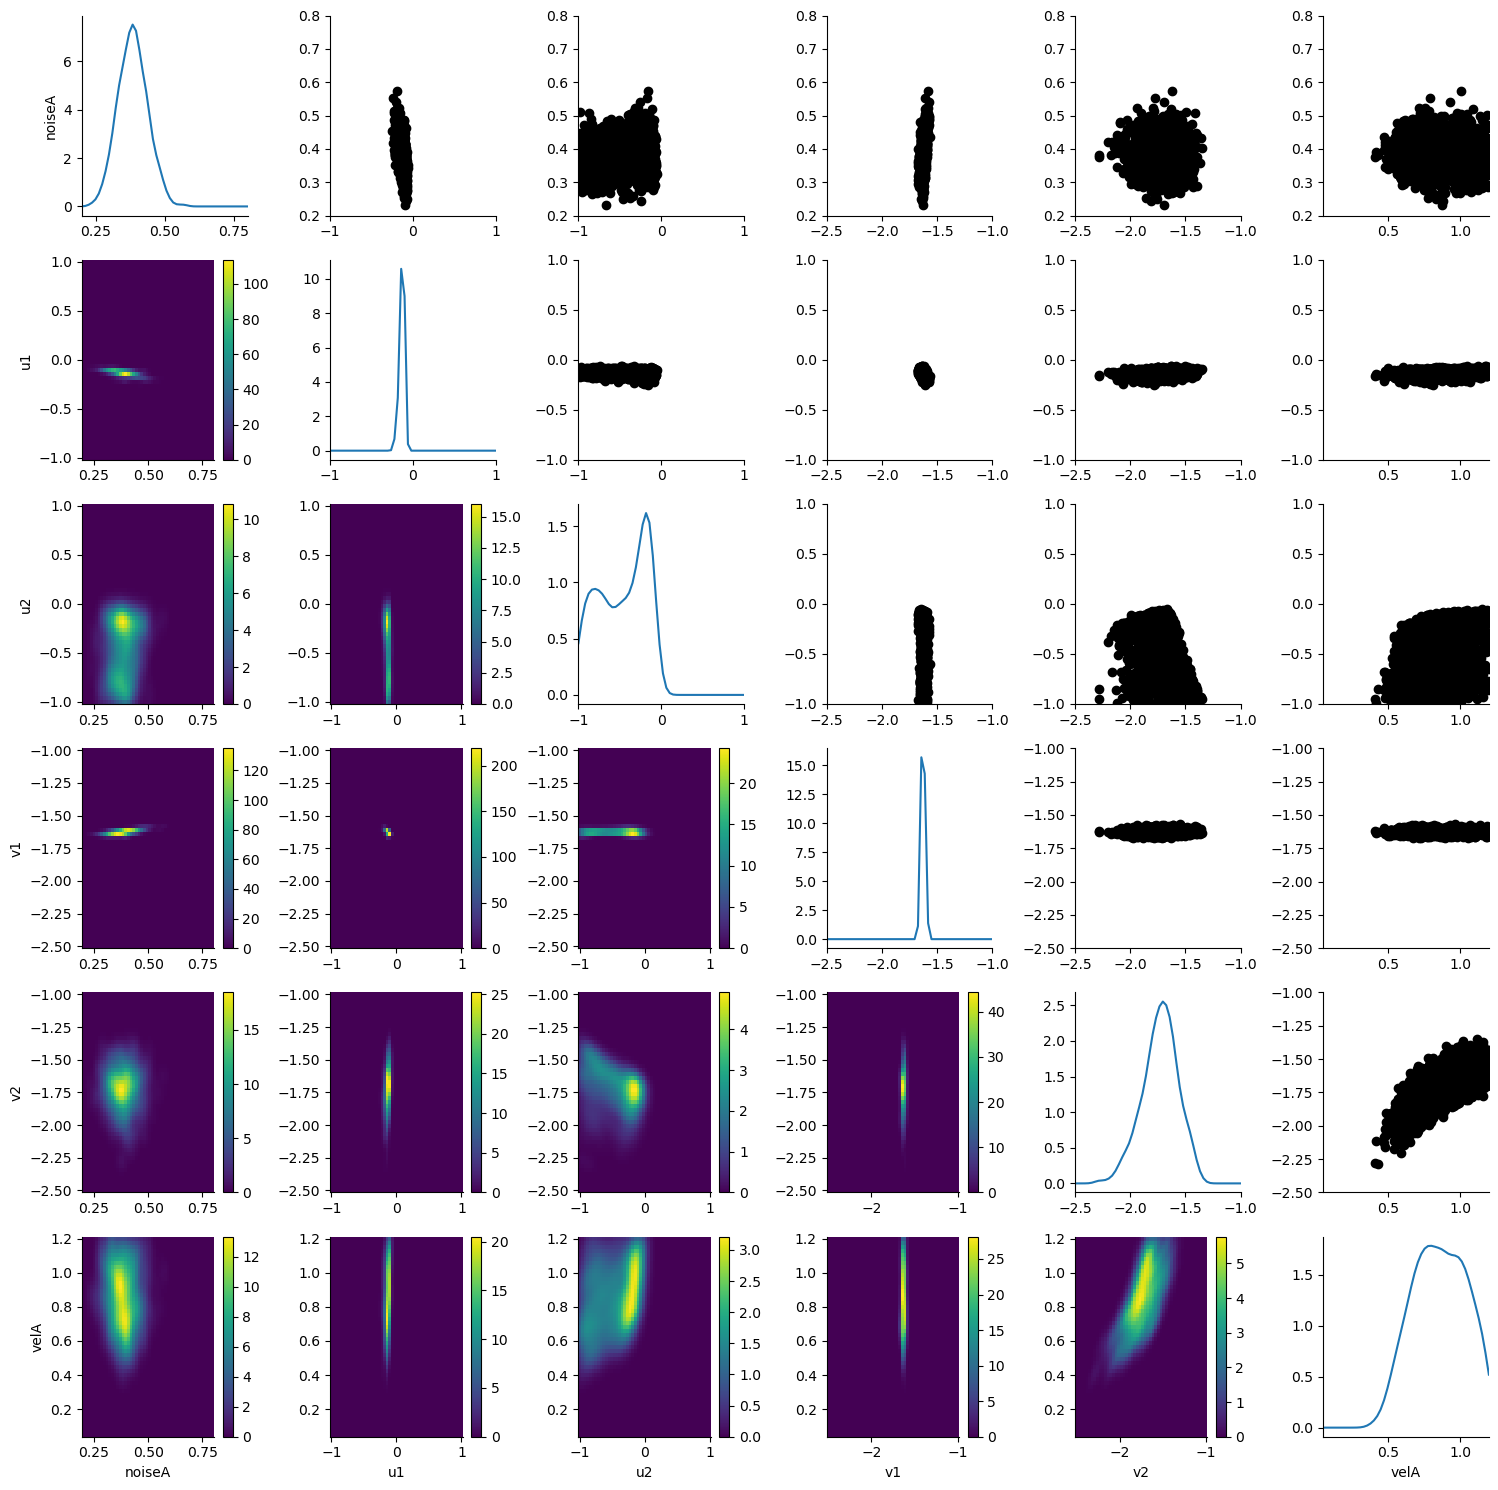

In [7]:
df, w = h.get_distribution(m=0)
plot_kde_matrix(df, w, limits=limits);

#### **4.2** Decrease of the $\varepsilon$-threshold over the 8 generations

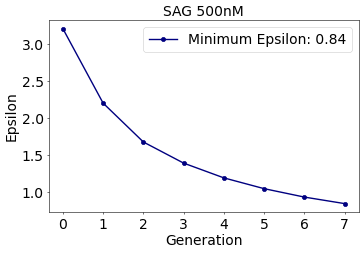

In [8]:
# Given epsilon values and x-axis points
epsilons = h.get_all_populations()["epsilon"].tolist()
epsilons=epsilons[1:]
x_axis = list(range(8)) 

# Create the line plot
plt.figure(figsize=(8, 5),dpi=50)
plt.plot(x_axis, epsilons, marker='o', linestyle='-', color='navy', linewidth=2, 
         label=f"Minimum Epsilon: {min(epsilons):.2f}")

plt.xlabel("Generation", fontsize=20)
plt.ylabel("Epsilon", fontsize=20)
plt.title("SAG 500nM", fontsize=20)
plt.legend(loc="upper right", fontsize=20)
plt.grid(False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

### **5.** Distributions of the simulated proportions for the parameters accepted by the ABC fitting

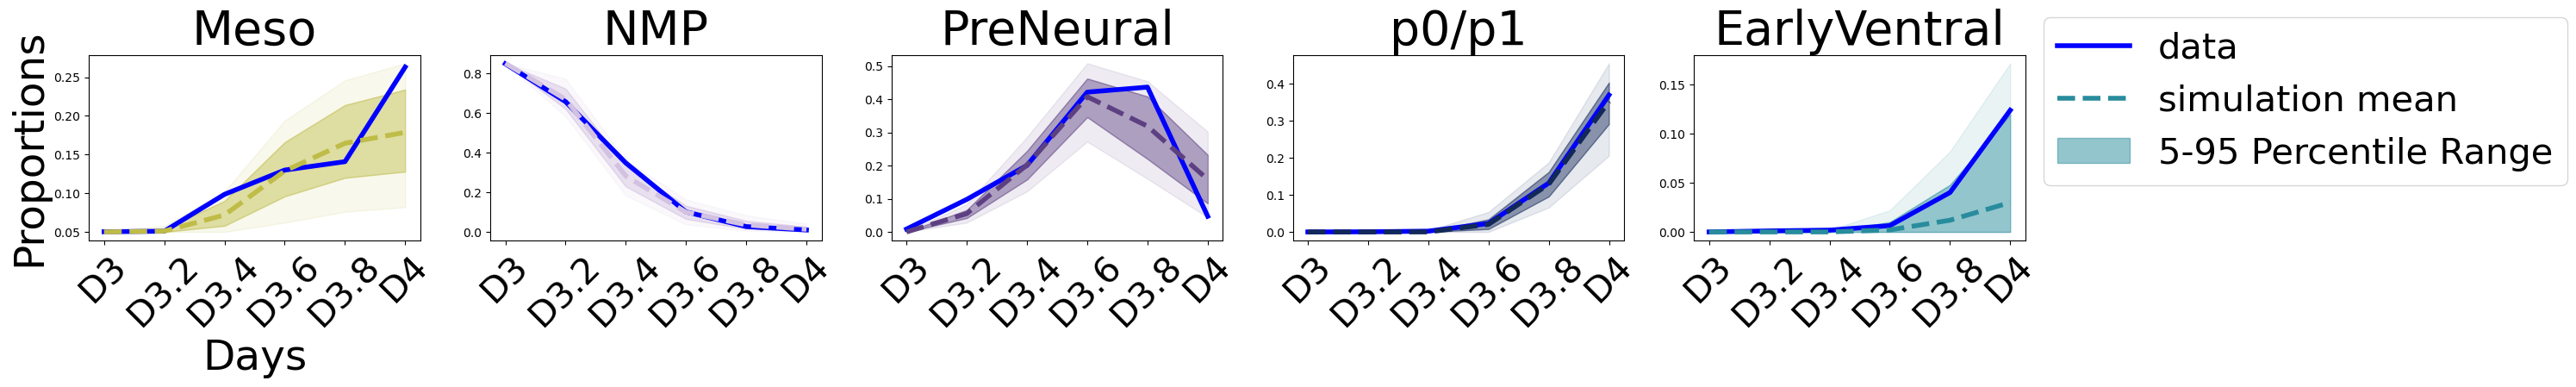

In [9]:
# process_simulations / simulation_todf come from the core; the plotting
# helper plot_tendencies lives in fitting_plots.
from fitting_core import process_simulations, simulation_todf
from fitting_plots import plot_tendencies

# States, colours and timepoints for the plot
states=['Meso','NMP','PreNeural','p0/p1','EarlyVentral']
colorpalette={'NMP':'#D2C1E1','Meso':'#BFBC47', 'PreNeural':'#5D4082','p0/p1':'#122859', 'EarlyVentral':'#288c9c'}
x_labels = ['D3','D3.2','D3.4','D3.6','D3.8','D4'] #timepoints

# Accepted simulations (first-decisions drops no timepoints -> idx_remove=())
simulation_accepted, dist, simulation_mean = process_simulations(population_size, h, Xdata, parSDE, states, idx_remove=())
# experimental data
data1 = pd.DataFrame(adata1.values.reshape(6,5),columns=states,index=x_labels)

# plot distributions
plot_tendencies(states, x_labels, simulation_accepted, data1, colorpalette)

#### **5.1** Barplots

Side-by-side stacked barplots of the **experimental** and **simulated** average proportions at each timepoint. The first-decisions model keeps every timepoint (nothing is dropped), so `x_labels` is the full list of days and every row of the simulated means is shown. `simulation_mean` is reshaped to (day, state); the experimental side reuses `adata1`. There is no held-out FP state in this model.

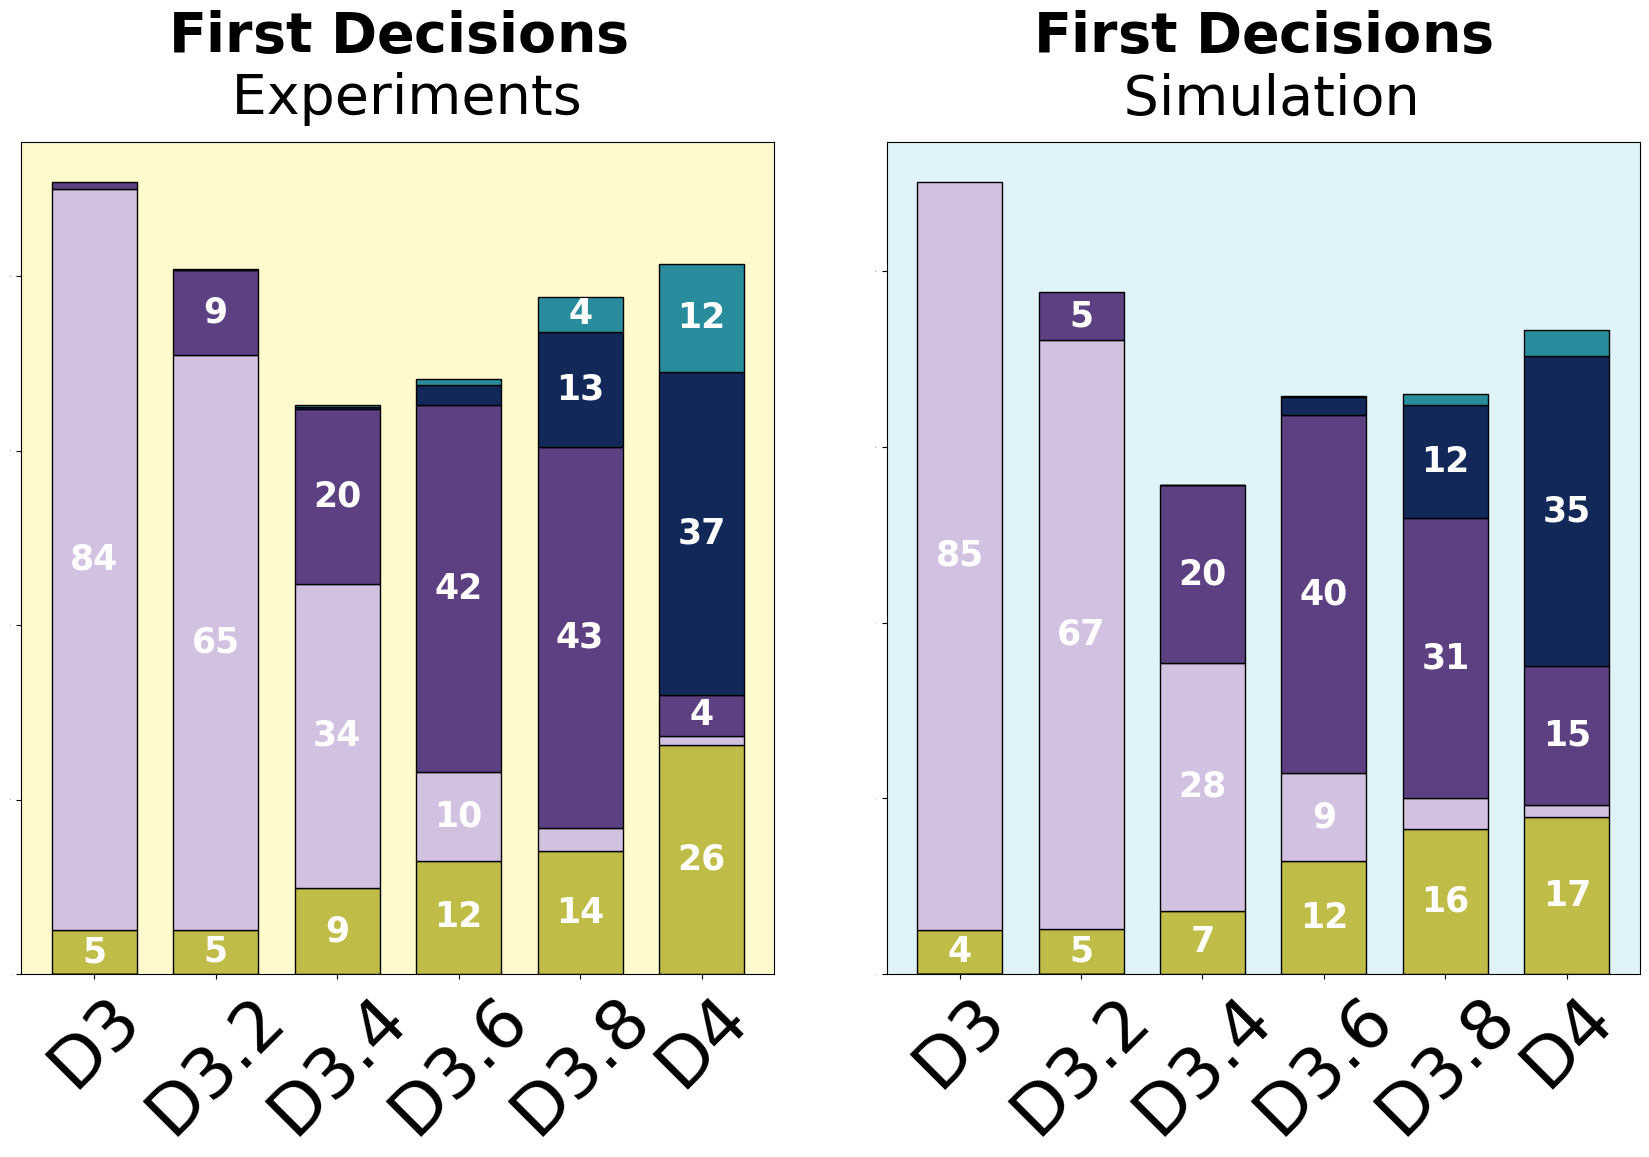

In [10]:
# Usage
from fitting_plots import plot_data

# First-decisions keeps all timepoints (nothing dropped), so x_labels is the full
# day list and we keep every row of the simulated means.
states = ['Meso','NMP','PreNeural','p0/p1','EarlyVentral']  # attractor clusters (columns)
x_labels = ['D3','D3.2','D3.4','D3.6','D3.8','D4']          # timepoints shown

# Reshape simulated means to (day, state) -- no dropped days, no FP column here.
simulated_data = pd.DataFrame(simulation_mean.reshape(len(x_labels), len(states)), columns=states)
# Experimental proportions for the same days.
data1 = pd.DataFrame(adata1.values.reshape(len(x_labels), len(states)), columns=states, index=x_labels)

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.tight_layout(pad=5)

# barplot of the experimental proportions (average)
plot_data(
    ax=axes[0],
    data=data1,
    title=r'$\bf{First\ Decisions}$',
    x_labels=x_labels,
    palette=colorpalette,
    background="data")

# barplot of the simulated proportions (average)
plot_data(
    ax=axes[1],
    data=simulated_data,
    title=r'$\bf{First\ Decisions}$',
    x_labels=x_labels,
    palette=colorpalette,
    background="simulation")

plt.show()


### **6.** Posterior parameter distributions of the sub-landscapes parameters

![Alt text](Github_FirstDecisionsLandscapes.jpg)

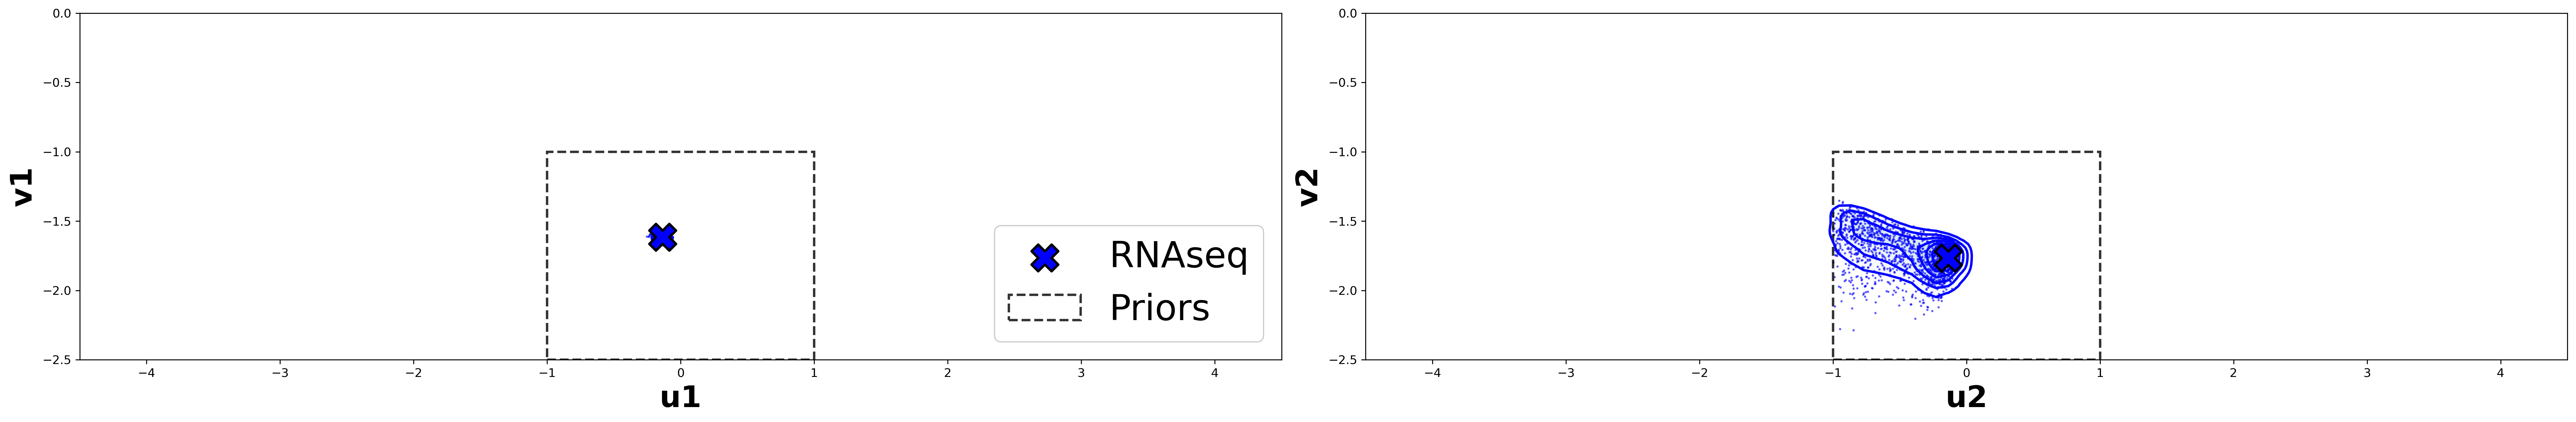

In [11]:
# Model-specific parameter-density plot (stays in the standalone module)
from fitting_plots import plot_parameters

plot_parameters(df)

### **7.** Save Results

In [12]:
Xsim_df=simulation_todf(states, x_labels, simulation_accepted)

# Save simulated proportions
Xsim_df.to_csv(wd+'NMPFlip_simulation.csv', index=False)
# Add distance to experimental data and save parameters
df['distance']=dist
df.to_csv(wd+'NMPFlip_parameters.csv', index=False)

# Save probability weights for posterior
#dw=pd.DataFrame(w,columns=['w'])
#dw.to_csv(wd+'NMPFlip_weights.csv', index=False)

In [13]:
Xsim_df.head(3)

,Meso-D3,NMP-D3,PreNeural-D3,p0/p1-D3,EarlyVentral-D3,Meso-D3.2,NMP-D3.2,PreNeural-D3.2,p0/p1-D3.2,EarlyVentral-D3.2,...,Meso-D3.8,NMP-D3.8,PreNeural-D3.8,p0/p1-D3.8,EarlyVentral-D3.8,Meso-D4,NMP-D4,PreNeural-D4,p0/p1-D4,EarlyVentral-D4
0,0.05,0.852,0.0,0.0,0.0,0.050,0.696,0.050,0.0,0.0,...,0.166,0.03,0.416,0.112,0.000,0.178,0.010,0.226,0.334,0.000
1,0.05,0.852,0.0,0.0,0.0,0.050,0.678,0.060,0.0,0.0,...,0.160,0.05,0.418,0.150,0.000,0.172,0.012,0.260,0.338,0.000
2,0.05,0.852,0.0,0.0,0.0,0.054,0.712,0.062,0.0,0.0,...,0.100,0.06,0.346,0.128,0.018,0.112,0.022,0.136,0.372,0.042


In [14]:
df.head(3)

name,noiseA,u1,u2,v1,v2,velA,distance
id,,,,,,,
21003,0.346439,-0.111933,-0.551880,-1.635293,-1.644199,0.865000,0.786
21004,0.389077,-0.134980,-0.660938,-1.618551,-1.484157,1.157384,0.820
21005,0.366434,-0.179871,-0.191741,-1.608172,-1.746578,0.968536,0.800
